# EEG Training Monitor

This notebook mirrors the training pipeline in a step-by-step format so progress can be tracked while running each cell.

Workflow:

1. Load split data and verify train/test scope.
2. Detect class imbalance and set class-weight policy automatically.
3. Run GroupKFold on train only (no test leakage).
4. Compare baseline vs candidate models.
5. Select best model by CV macro F1, then evaluate once on test.
6. Plot confusion matrix and top per-class recall diagnostics.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
DATA_PATH = Path('outputs/processed/features_with_split.csv')
REPORT_DIR = Path('outputs/reports')
REPORT_DIR.mkdir(parents=True, exist_ok=True)

GROUP_COL = 'id'
LABEL_COL = 'label'
SPLIT_COL = 'split'
N_SPLITS = 3
SEED = 42
IMBALANCE_THRESHOLD = 2.0

assert DATA_PATH.exists(), f'Missing input file: {DATA_PATH}'
print('Using data file:', DATA_PATH)

Using data file: outputs/processed/features_with_split.csv


In [3]:
df = pd.read_csv(DATA_PATH)
required_cols = {GROUP_COL, LABEL_COL, SPLIT_COL}
missing = required_cols - set(df.columns)
if missing:
    raise KeyError(f'Missing required columns: {sorted(missing)}')

train_df = df[df[SPLIT_COL] == 'train'].copy()
test_df = df[df[SPLIT_COL] == 'test'].copy()

if train_df.empty or test_df.empty:
    raise RuntimeError('Both train and test splits must be non-empty.')

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in {GROUP_COL, LABEL_COL, SPLIT_COL}]

print('Shape:', df.shape)
print('Feature count:', len(feature_cols))
print('Rows | train:', len(train_df), 'test:', len(test_df))
print('Groups | train:', train_df[GROUP_COL].nunique(), 'test:', test_df[GROUP_COL].nunique())

Shape: (9959, 29)
Feature count: 21
Rows | train: 7058 test: 1628
Groups | train: 21 test: 5


In [4]:
x_train = train_df[feature_cols]
y_train = train_df[LABEL_COL].astype(str)
g_train = train_df[GROUP_COL].astype(str)

x_test = test_df[feature_cols]
y_test = test_df[LABEL_COL].astype(str)

label_counts = y_train.value_counts()
imbalance_ratio = float(label_counts.max() / max(label_counts.min(), 1))
class_weight_enabled = imbalance_ratio >= IMBALANCE_THRESHOLD

print('Train imbalance ratio (max/min):', f'{imbalance_ratio:.2f}x')
print('Auto class-weight enabled:', class_weight_enabled)
display(label_counts.head(15).to_frame('train_count'))

Train imbalance ratio (max/min): 31.62x
Auto class-weight enabled: True


,train_count
label,
relax,664
music,662
thinkOfItems-ver2,424
video-ver2,422
colorInstruction2,330
thinkOfItemsInstruction-ver2,281
thinkOfItems-ver1,241
video-ver1,240
colorInstruction1,223


In [5]:
def evaluate_with_groupkfold(name, estimator, x, y, groups, n_splits=3):
    unique_groups = groups.nunique()
    effective_splits = min(n_splits, unique_groups)
    if effective_splits < 2:
        raise RuntimeError('Need at least 2 unique groups for GroupKFold.')

    gkf = GroupKFold(n_splits=effective_splits)
    rows = []

    for fold_idx, (train_idx, val_idx) in enumerate(gkf.split(x, y, groups=groups), start=1):
        model = clone(estimator)
        model.fit(x.iloc[train_idx], y.iloc[train_idx])
        y_pred = model.predict(x.iloc[val_idx])
        y_true = y.iloc[val_idx]

        row = {
            'model': name,
            'fold': fold_idx,
            'accuracy': float(accuracy_score(y_true, y_pred)),
            'f1_macro': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
            'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        }
        rows.append(row)
        print(f"{name} | fold {fold_idx}/{effective_splits} | f1_macro={row['f1_macro']:.4f}")

    folds_df = pd.DataFrame(rows)
    summary = {
        'accuracy_mean': float(folds_df['accuracy'].mean()),
        'accuracy_std': float(folds_df['accuracy'].std(ddof=0)),
        'f1_macro_mean': float(folds_df['f1_macro'].mean()),
        'f1_macro_std': float(folds_df['f1_macro'].std(ddof=0)),
        'balanced_accuracy_mean': float(folds_df['balanced_accuracy'].mean()),
        'balanced_accuracy_std': float(folds_df['balanced_accuracy'].std(ddof=0)),
    }
    return summary, folds_df

def evaluate_on_test(model, x, y):
    y_pred = model.predict(x)
    return {
        'accuracy': float(accuracy_score(y, y_pred)),
        'f1_macro': float(f1_score(y, y_pred, average='macro', zero_division=0)),
        'balanced_accuracy': float(balanced_accuracy_score(y, y_pred)),
        'classification_report': classification_report(y, y_pred, output_dict=True, zero_division=0),
        'y_pred': y_pred,
    }

In [6]:
lr_class_weight = 'balanced' if class_weight_enabled else None # lr: logistic regression
rf_class_weight = 'balanced_subsample' if class_weight_enabled else None # rf: random forest

baseline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', DummyClassifier(strategy='most_frequent')),
])

candidates = {
    'logreg': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=4000, 
            solver='lbfgs', 
            class_weight=lr_class_weight, 
            random_state=SEED
        )),
    ]),
    'random_forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(
            n_estimators=100,
            max_depth=20,
            min_samples_leaf=2,
            class_weight=rf_class_weight,
            random_state=SEED,
            n_jobs=-1
        )),
    ]),
}

print('Candidate models:', list(candidates.keys()))
print('Class-weight enabled:', class_weight_enabled)

Candidate models: ['logreg', 'random_forest']
Class-weight enabled: True


In [7]:
baseline_cv_summary, baseline_folds = evaluate_with_groupkfold(
    name='baseline_dummy',
    estimator=baseline,
    x=x_train,
    y=y_train,
    groups=g_train,
    n_splits=N_SPLITS,
)

baseline_fit = clone(baseline).fit(x_train, y_train)
baseline_test = evaluate_on_test(baseline_fit, x_test, y_test)

print('Baseline CV summary:', baseline_cv_summary)
print('Baseline test metrics:', {k: baseline_test[k] for k in ['accuracy', 'f1_macro', 'balanced_accuracy']})
display(baseline_folds)

baseline_dummy | fold 1/3 | f1_macro=0.0026
baseline_dummy | fold 2/3 | f1_macro=0.0025
baseline_dummy | fold 3/3 | f1_macro=0.0026
Baseline CV summary: {'accuracy_mean': 0.09352670752618514, 'accuracy_std': 0.0003170416360809078, 'f1_macro_mean': 0.002553060192821444, 'f1_macro_std': 7.913581608445619e-06, 'balanced_accuracy_mean': 0.014925373134328358, 'balanced_accuracy_std': 0.0}
Baseline test metrics: {'accuracy': 0.09152334152334152, 'f1_macro': 0.0025029607169554592, 'balanced_accuracy': 0.014925373134328358}


,model,fold,accuracy,f1_macro,balanced_accuracy
0,baseline_dummy,1,0.093458,0.002551,0.014925
1,baseline_dummy,2,0.093177,0.002544,0.014925
2,baseline_dummy,3,0.093945,0.002563,0.014925


In [8]:
model_results = {}
all_folds = [baseline_folds]

for name, estimator in candidates.items():
    cv_summary, fold_df = evaluate_with_groupkfold(
        name=name, estimator=estimator, x=x_train, y=y_train, groups=g_train, n_splits=N_SPLITS
    )
    fitted = clone(estimator).fit(x_train, y_train)
    test_metrics = evaluate_on_test(fitted, x_test, y_test)

    model_results[name] = {
        'cv_summary': cv_summary,
        'cv_folds': fold_df.copy(),
        'fitted_model': fitted,
        'test_metrics': test_metrics,
    }
    all_folds.append(fold_df)

summary_rows = []
for name, r in model_results.items():
    summary_rows.append({
        'model': name,
        'cv_f1_macro_mean': r['cv_summary']['f1_macro_mean'],
        'cv_balanced_accuracy_mean': r['cv_summary']['balanced_accuracy_mean'],
        'test_f1_macro': r['test_metrics']['f1_macro'],
        'test_balanced_accuracy': r['test_metrics']['balanced_accuracy'],
    })

summary_df = pd.DataFrame(summary_rows).sort_values('cv_f1_macro_mean', ascending=False)
display(summary_df)

logreg | fold 1/3 | f1_macro=0.0254
logreg | fold 2/3 | f1_macro=0.0166
logreg | fold 3/3 | f1_macro=0.0159
random_forest | fold 1/3 | f1_macro=0.0301
random_forest | fold 2/3 | f1_macro=0.0216
random_forest | fold 3/3 | f1_macro=0.0230


,model,cv_f1_macro_mean,cv_balanced_accuracy_mean,test_f1_macro,test_balanced_accuracy
1,random_forest,0.024931,0.028906,0.019545,0.020925
0,logreg,0.019269,0.029941,0.009698,0.019035


In [9]:
best_name = summary_df.iloc[0]['model']
best_model = model_results[best_name]['fitted_model']
best_test = model_results[best_name]['test_metrics']

print('Selected model:', best_name)
print('Final test metrics:')
print('  accuracy         =', round(best_test['accuracy'], 4))
print('  f1_macro         =', round(best_test['f1_macro'], 4))
print('  balanced_accuracy=', round(best_test['balanced_accuracy'], 4))

Selected model: random_forest
Final test metrics:
  accuracy         = 0.0522
  f1_macro         = 0.0195
  balanced_accuracy= 0.0209


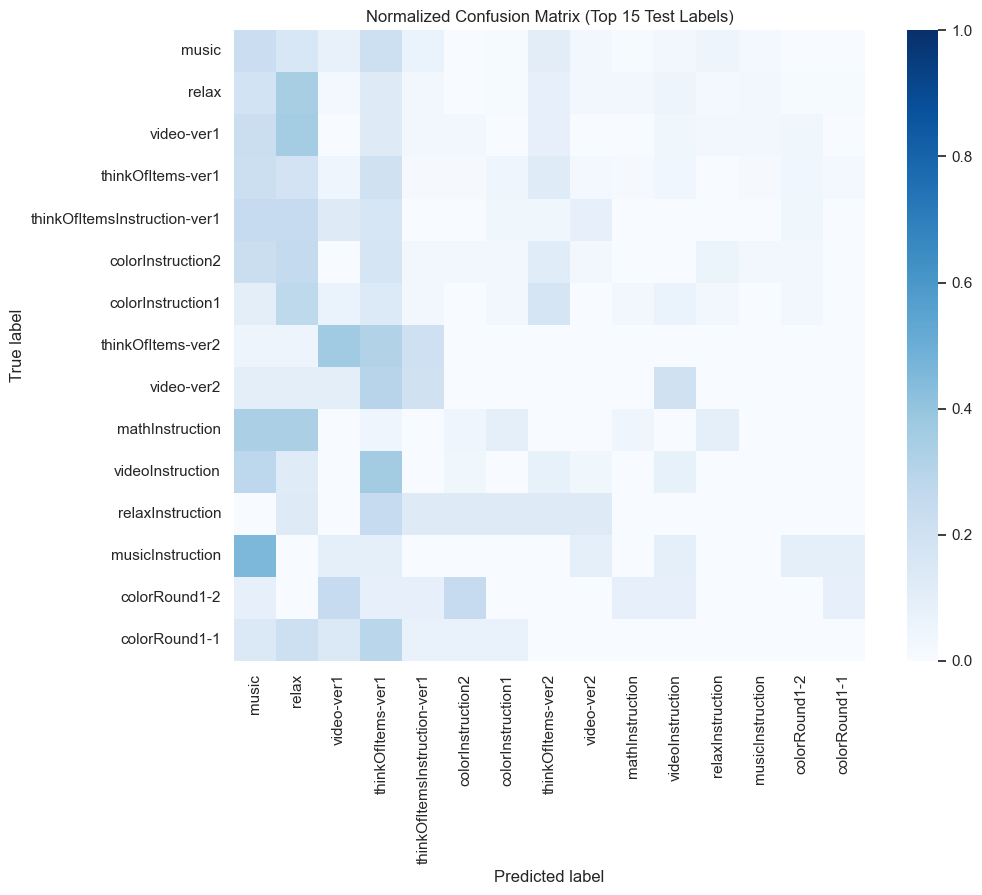

In [10]:
# Confusion matrix for top labels by true support on test.
TOP_N = 15
test_support = y_test.value_counts()
top_labels = test_support.head(TOP_N).index.tolist()

mask = y_test.isin(top_labels)
y_true_top = y_test[mask]
y_pred_top = pd.Series(best_test['y_pred'], index=y_test.index)[mask]

cm = confusion_matrix(y_true_top, y_pred_top, labels=top_labels, normalize='true')
cm_df = pd.DataFrame(cm, index=top_labels, columns=top_labels)

plt.figure(figsize=(11, 9))
sns.heatmap(cm_df, cmap='Blues', vmin=0, vmax=1, square=True)
plt.title(f'Normalized Confusion Matrix (Top {TOP_N} Test Labels)')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()

In [11]:
# Top per-class recall diagnostics (test set).
report_df = pd.DataFrame(best_test['classification_report']).T
per_class = report_df.loc[~report_df.index.isin(['accuracy', 'macro avg', 'weighted avg'])].copy()
per_class = per_class.sort_values('recall', ascending=False)

print('Best-recalled classes:')
display(per_class[['precision', 'recall', 'f1-score', 'support']].head(15))

print('Worst-recalled classes:')
display(per_class[['precision', 'recall', 'f1-score', 'support']].tail(15))

Best-recalled classes:


,precision,recall,f1-score,support
relax,0.196429,0.221477,0.208202,149.0
blink5,0.111111,0.200000,0.142857,10.0
music,0.142857,0.140000,0.141414,150.0
thinkOfItems-ver1,0.109589,0.135593,0.121212,118.0
colorRound3-2,0.200000,0.100000,0.133333,10.0
math9,0.062500,0.083333,0.071429,12.0
math12,0.040000,0.076923,0.052632,13.0
videoInstruction,0.064516,0.071429,0.067797,28.0
colorRound2-6,0.071429,0.066667,0.068966,15.0
colorRound2-2,0.027778,0.066667,0.039216,15.0


Worst-recalled classes:


,precision,recall,f1-score,support
colorRound3-3,0.0,0.0,0.0,10.0
colorRound5-4,0.0,0.0,0.0,14.0
colorRound3-4,0.0,0.0,0.0,10.0
colorRound3-5,0.0,0.0,0.0,9.0
colorRound3-6,0.0,0.0,0.0,10.0
colorRound4-1,0.0,0.0,0.0,5.0
colorRound4-2,0.0,0.0,0.0,5.0
colorRound4-3,0.0,0.0,0.0,5.0
colorRound4-4,0.0,0.0,0.0,4.0
colorRound4-5,0.0,0.0,0.0,6.0


In [12]:
# Persist notebook run metrics so progress over iterations is easy to compare.
artifact = {
    'config': {
        'data_path': str(DATA_PATH),
        'group_col': GROUP_COL,
        'label_col': LABEL_COL,
        'split_col': SPLIT_COL,
        'n_splits': N_SPLITS,
        'imbalance_threshold': IMBALANCE_THRESHOLD,
        'seed': SEED,
    },
    'data': {
        'rows_total': int(len(df)),
        'rows_train': int(len(train_df)),
        'rows_test': int(len(test_df)),
        'feature_count': int(len(feature_cols)),
        'imbalance_ratio': float(imbalance_ratio),
        'class_weight_enabled': bool(class_weight_enabled),
    },
    'baseline': {
        'cv_summary': baseline_cv_summary,
        'test': {k: baseline_test[k] for k in ['accuracy', 'f1_macro', 'balanced_accuracy']},
    },
    'candidates': {
        name: {
            'cv_summary': res['cv_summary'],
            'test': {k: res['test_metrics'][k] for k in ['accuracy', 'f1_macro', 'balanced_accuracy']},
        }
        for name, res in model_results.items()
    },
    'selected_model': {
        'name': best_name,
        'test': {k: best_test[k] for k in ['accuracy', 'f1_macro', 'balanced_accuracy']},
    },
}

out_path = REPORT_DIR / 'training_monitor_results.json'
out_path.write_text(json.dumps(artifact, indent=2), encoding='utf-8')
print('Saved:', out_path)

Saved: outputs/reports/training_monitor_results.json


## Focused Top-k Classes Experiment

This section reruns training with only:

- `relax`
- `music`
- `video` (from `video-ver1`, `video-ver2`)
- `thinkOfItems` (from `thinkOfItems-ver1`, `thinkOfItems-ver2`)


In [17]:
# Build k-class target from the existing dataframe.
label_map_4 = {
    "relax": "relax",
    "music": "music",
    # "video-ver1": "video",
    # "video-ver2": "video",
    # "thinkOfItems-ver1": "thinkOfItems",
    # "thinkOfItems-ver2": "thinkOfItems",
}

df4 = df.copy()
df4["label_4class"] = df4[LABEL_COL].map(label_map_4)
df4 = df4[df4["label_4class"].notna()].copy()

train4 = df4[df4[SPLIT_COL] == "train"].copy()
test4 = df4[df4[SPLIT_COL] == "test"].copy()

x_train4 = train4[feature_cols]
y_train4 = train4["label_4class"].astype(str)
g_train4 = train4[GROUP_COL].astype(str)

x_test4 = test4[feature_cols]
y_test4 = test4["label_4class"].astype(str)

print("Rows (4-class) | train:", len(train4), "test:", len(test4))
print("Subjects       | train:", train4[GROUP_COL].nunique(), "test:", test4[GROUP_COL].nunique())
print()
print("Class counts by split:")
display(pd.crosstab(df4[SPLIT_COL], df4["label_4class"]))

Rows (4-class) | train: 1326 test: 299
Subjects       | train: 21 test: 5

Class counts by split:


label_4class,music,relax
split,,
test,150,149
train,662,664
val,120,121


In [18]:
# Automatic imbalance handling for the 4-class target.
counts4 = y_train4.value_counts()
imbalance_ratio4 = float(counts4.max() / max(counts4.min(), 1))
class_weight_enabled4 = imbalance_ratio4 >= IMBALANCE_THRESHOLD

lr_class_weight4 = "balanced" if class_weight_enabled4 else None
rf_class_weight4 = "balanced_subsample" if class_weight_enabled4 else None

baseline4 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", DummyClassifier(strategy="most_frequent")),
])

candidates4 = {
    "logreg": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=4000, solver="lbfgs", class_weight=lr_class_weight4, random_state=SEED)),
    ]),
    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=100,
            max_depth=20,
            min_samples_leaf=2,
            class_weight=rf_class_weight4,
            random_state=SEED,
            n_jobs=-1,
        )),
    ]),
}

print(f"4-class train imbalance ratio: {imbalance_ratio4:.2f}x")
print("Class-weight enabled:", class_weight_enabled4)

baseline4_cv, baseline4_folds = evaluate_with_groupkfold(
    name="baseline_dummy_4class",
    estimator=baseline4,
    x=x_train4,
    y=y_train4,
    groups=g_train4,
    n_splits=N_SPLITS,
)
baseline4_fit = clone(baseline4).fit(x_train4, y_train4)
baseline4_test = evaluate_on_test(baseline4_fit, x_test4, y_test4)

results4 = {}
summary_rows4 = []

for name, estimator in candidates4.items():
    cv_summary4, fold_df4 = evaluate_with_groupkfold(
        name=name + "_4class",
        estimator=estimator,
        x=x_train4,
        y=y_train4,
        groups=g_train4,
        n_splits=N_SPLITS,
    )
    fit4 = clone(estimator).fit(x_train4, y_train4)
    test_metrics4 = evaluate_on_test(fit4, x_test4, y_test4)

    results4[name] = {
        "cv_summary": cv_summary4,
        "cv_folds": fold_df4,
        "model": fit4,
        "test": test_metrics4,
    }
    summary_rows4.append({
        "model": name,
        "cv_f1_macro": cv_summary4["f1_macro_mean"],
        "cv_balanced_accuracy": cv_summary4["balanced_accuracy_mean"],
        "test_f1_macro": test_metrics4["f1_macro"],
        "test_balanced_accuracy": test_metrics4["balanced_accuracy"],
    })

summary4 = pd.DataFrame(summary_rows4).sort_values("cv_f1_macro", ascending=False)
print("\n4-class model comparison:")
display(summary4)

4-class train imbalance ratio: 1.00x
Class-weight enabled: False
baseline_dummy_4class | fold 1/3 | f1_macro=0.3333
baseline_dummy_4class | fold 2/3 | f1_macro=0.3339
baseline_dummy_4class | fold 3/3 | f1_macro=0.3339
logreg_4class | fold 1/3 | f1_macro=0.6207
logreg_4class | fold 2/3 | f1_macro=0.5423
logreg_4class | fold 3/3 | f1_macro=0.5085
random_forest_4class | fold 1/3 | f1_macro=0.5103
random_forest_4class | fold 2/3 | f1_macro=0.5227
random_forest_4class | fold 3/3 | f1_macro=0.4745

4-class model comparison:


,model,cv_f1_macro,cv_balanced_accuracy,test_f1_macro,test_balanced_accuracy
0,logreg,0.557158,0.558397,0.611688,0.612148
1,random_forest,0.502505,0.519920,0.578213,0.578702


Selected 4-class model: logreg
Test metrics:
  accuracy         = 0.612
  f1_macro         = 0.6117
  balanced_accuracy= 0.6121


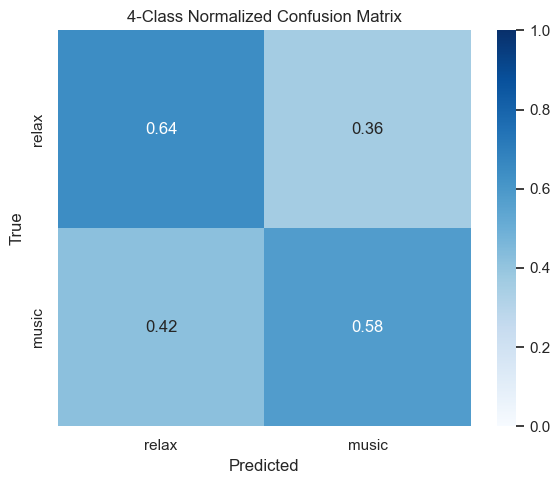

Saved: outputs/reports/training_monitor_results_4class.json


In [20]:
# Final selection, diagnostics, and export for the 4-class run.
best_name4 = summary4.iloc[0]["model"]
best4 = results4[best_name4]
best4_test = best4["test"]

print("Selected 4-class model:", best_name4)
print("Test metrics:")
print("  accuracy         =", round(best4_test["accuracy"], 4))
print("  f1_macro         =", round(best4_test["f1_macro"], 4))
print("  balanced_accuracy=", round(best4_test["balanced_accuracy"], 4))

labels4_order = [
    "relax", 
    "music", 
    # "video", 
    # "thinkOfItems"
    ]
y_pred4 = pd.Series(best4_test["y_pred"], index=y_test4.index)

cm4 = confusion_matrix(y_test4, y_pred4, labels=labels4_order, normalize="true")
cm4_df = pd.DataFrame(cm4, index=labels4_order, columns=labels4_order)

plt.figure(figsize=(6, 5))
sns.heatmap(cm4_df, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
plt.title("4-Class Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

artifact4 = {
    "target": "4class",
    "label_mapping": label_map_4,
    "train_rows": int(len(train4)),
    "test_rows": int(len(test4)),
    "imbalance_ratio": float(imbalance_ratio4),
    "class_weight_enabled": bool(class_weight_enabled4),
    "baseline": {
        "cv": baseline4_cv,
        "test": {k: baseline4_test[k] for k in ["accuracy", "f1_macro", "balanced_accuracy"]},
    },
    "candidates": {
        name: {
            "cv": r["cv_summary"],
            "test": {k: r["test"][k] for k in ["accuracy", "f1_macro", "balanced_accuracy"]},
        }
        for name, r in results4.items()
    },
    "selected_model": {
        "name": best_name4,
        "test": {k: best4_test[k] for k in ["accuracy", "f1_macro", "balanced_accuracy"]},
    },
}

out_4class_results = REPORT_DIR / "training_monitor_results_4class.json"
out_4class_results.write_text(json.dumps(artifact4, indent=2), encoding="utf-8")
print("Saved:", out_4class_results)